# One-run comparison of the three ABBA methods

This experiment compares `ExplicitABBA`, `SymmetricProjectedABBA`, and `SemiImplicitABBA` on the same guiding-center problem. Each method is run exactly once with one common integration step, one initial boundary, and one saved-time grid.

Each method's runtime is measured during its sole simulation after subtracting time spent inside the symplecticity observer. The videos and geometric diagnostics therefore come from the same run without charging finite-difference defect evaluation or diagnostic persistence to the method. `SemiImplicitABBA` still includes its method-owned exact tangent propagation because that operation is part of the integrator itself.

Trajectory similarity is measured particle by particle on the periodic cell. Coordinate differences use the minimum-image convention before computing the RMS and maximum Euclidean displacement.

In [1]:
%matplotlib inline

import numpy as np

from studies import (
    ABBAComparisonConfig,
    RandomPotentialConfig,
    centered_circle,
    run_abba_comparison,
)
from visualization import display_animation

## Reproducible configuration

The random potential, seed, interpolation order, boundary geometry, physical radius, integration interval, integration step, observation interval, finite-difference scale, and Newton tolerances are explicit below. The common step $\Delta t=\pi/40$ is the middle refinement used in the earlier explicit-ABBA study. The interval $[0,2\pi]$ gives 80 complete steps and 41 synchronized animation frames while keeping the finite-difference diagnostics practical. Progress rendering is disabled so terminal I/O does not contaminate the method timings.

In [2]:
potential_config = RandomPotentialConfig(
    amplitude=0.7,
    max_wave_number=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
potential = potential_config.build()

circle_radius = 0.5
circle_points = 8
rho = 0.3
circle = centered_circle(
    potential,
    radius=circle_radius,
    points=circle_points,
    rho=rho,
)

finite_difference_relative_step = float(np.cbrt(np.finfo(float).eps))
comparison_config = ABBAComparisonConfig(
    integration_step=np.pi / 40,
    step_label=r"$\Delta t=\pi/40$",
    t_span=(0.0, 2 * np.pi),
    save_interval=np.pi / 20,
    chunk_size=16,
    progress=False,
    block_prefix="three_abba_comparison",
    finite_difference_relative_step=finite_difference_relative_step,
    newton_absolute_tolerance=1e-13,
    newton_relative_tolerance=1e-12,
    newton_max_iterations=12,
)

print(potential_config)
print(comparison_config)
print(
    f"Circle: {circle_points} points; radius={circle_radius}; rho={rho}; "
    f"{comparison_config.output_sample_count} saved states"
)

RandomPotentialConfig(amplitude=0.7, max_wave_number=25, nx=64, ny=64, seed=27, interpolation_order=5)
ABBAComparisonConfig(integration_step=0.07853981633974483, step_label='$\\Delta t=\\pi/40$', t_span=(0.0, 6.283185307179586), save_interval=0.15707963267948966, rho=None, chunk_size=16, progress=False, block_prefix='three_abba_comparison', finite_difference_relative_step=6.0554544523933395e-06, newton_absolute_tolerance=1e-13, newton_relative_tolerance=1e-12, newton_max_iterations=12)
Circle: 8 points; radius=0.5; rho=0.3; 41 saved states


## One simulation per ABBA method

The study runs the explicit averaged map, the symmetric projected map with centered-difference flow Jacobians, and the semi-implicit exact-tangent map once each. All three runs persist area and symplecticity observations under this notebook's output directory, while observer callback time is recorded separately from simulation time.

In [3]:
result = run_abba_comparison(
    potential,
    circle,
    notebook_path=(
        "notebooks/experiments/abba_comparison/"
        "compare_abba_methods.ipynb"
    ),
    config=comparison_config,
    metadata={
        **potential_config.metadata(),
        "circle_radius": circle_radius,
        "comparison_kind": "single_run_three_abba_methods",
    },
)
result.print_summary()

                  method    runtime [s]   vs fastest     max |area error|      max flow defect
            ExplicitABBA       0.024179        1.000       7.23552840e-02       1.60219825e-07
  SymmetricProjectedABBA       0.087630        3.624       7.23552859e-02       2.39972747e-09
        SemiImplicitABBA       0.162928        6.738       7.23552859e-02       8.95310349e-16

Periodic physical-trajectory distances:
                                      method pair       global RMS          maximum        final RMS    final maximum
           ExplicitABBA vs SymmetricProjectedABBA   7.28876162e-09   3.31881878e-08   1.57487731e-08   3.31881878e-08
                 ExplicitABBA vs SemiImplicitABBA   7.28876162e-09   3.31881878e-08   1.57487731e-08   3.31881878e-08
       SymmetricProjectedABBA vs SemiImplicitABBA   0.00000000e+00   0.00000000e+00   0.00000000e+00   0.00000000e+00

Runtime excludes time spent evaluating and persisting symplecticity diagnostics. SemiImplicitABBA still in

## Execution-time comparison

These are single-run wall-clock measurements of the numerical simulations after subtracting all time spent inside the symplecticity observer. Consequently, centered finite-difference evaluations, defect calculations, buffered diagnostic writes, and final persistence are excluded. The semi-implicit value retains exact tangent propagation because `SemiImplicitABBA` computes that tangent internally before notifying the observer.

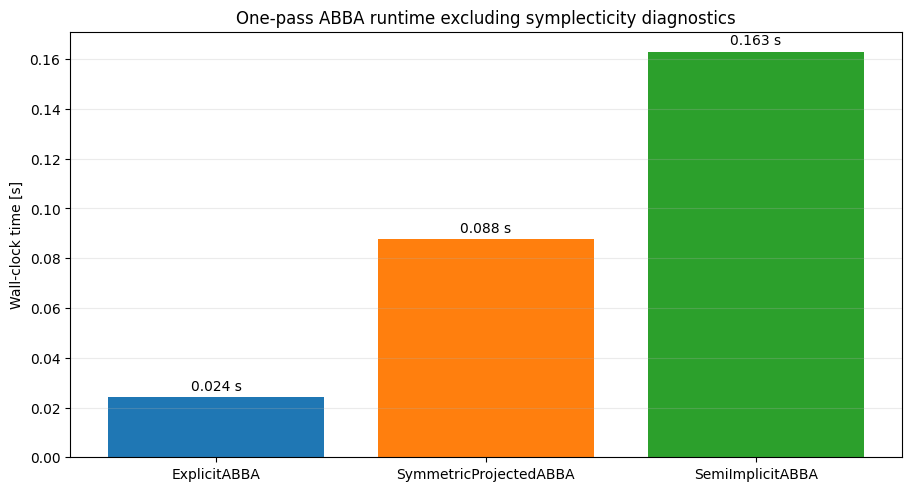

In [4]:
runtime_figure, runtime_axis = result.plot_runtime_comparison()

## Physical-trajectory similarity

The dashed curves show the RMS particle displacement and the solid curves show the maximum particle displacement for each method pair. Exact zeros are drawn at a floating-point display floor on the logarithmic axis. `SymmetricProjectedABBA` and `SemiImplicitABBA` are expected to agree exactly because they use the same projected physical step; the latter additionally propagates the exact tangent.

Projected and semi-implicit physical trajectories are bitwise identical.


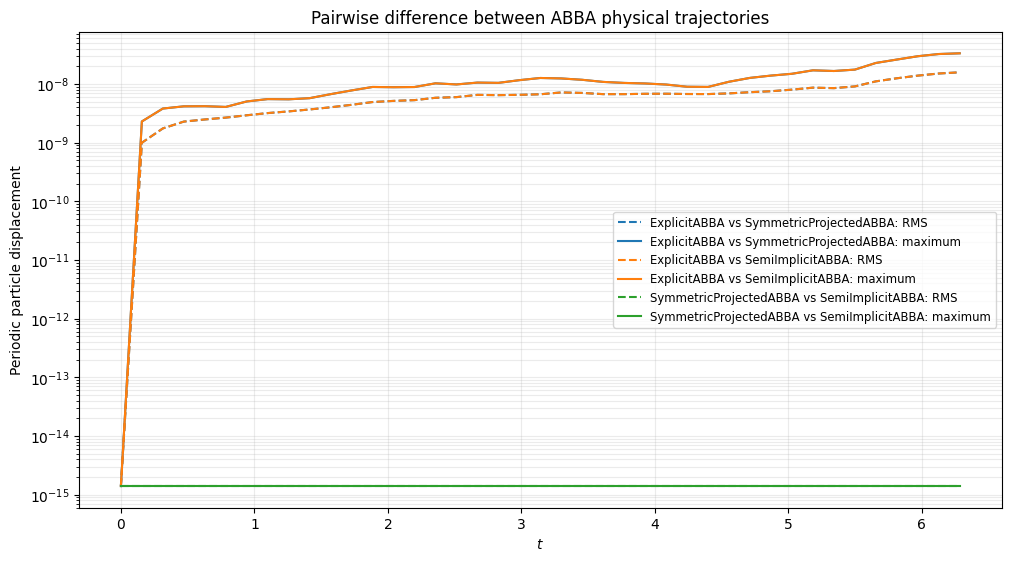

In [5]:
trajectory_figure, trajectory_axis = result.plot_trajectory_differences()

projected_states = result.solutions["SymmetricProjectedABBA"].states
semiimplicit_states = result.solutions["SemiImplicitABBA"].states
assert np.array_equal(projected_states, semiimplicit_states)
print("Projected and semi-implicit physical trajectories are bitwise identical.")

## Explicit ABBA video

The video synchronizes the transported contour, relative polygon-area error, and accumulated finite-difference symplecticity defect for the explicit averaged map.

In [6]:
display_animation(
    result.animate("ExplicitABBA", frames=None, interval=120)
)

## Symmetric-projected ABBA video

The video shows the same three synchronized views for Hairer's symmetric projection, with the physical-flow defect obtained by centered differentiation of the emitted finite-tolerance map.

In [7]:
display_animation(
    result.animate("SymmetricProjectedABBA", frames=None, interval=120)
)

## Semi-implicit ABBA video

The semi-implicit video uses the exact implicit-function tangent for its accumulated symplecticity defect. Its contour and area history should coincide with the symmetric-projected video.

In [8]:
display_animation(
    result.animate("SemiImplicitABBA", frames=None, interval=120)
)

## Interpretation

The timing table compares one unreplicated run per method and is therefore descriptive rather than a statistical benchmark. It excludes observer-owned symplecticity work, while the semi-implicit method retains the cost of propagating its exact tangent. The trajectory-distance table separates this computational distinction from the physical path. In particular, zero projected-versus-semi-implicit distance confirms that their different tangent handling does not alter the shared physical trajectory.